<a href="https://colab.research.google.com/github/mbmanoj904-hue/Generative-ai/blob/main/Cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate Fake Uber Data for 500 rides
np.random.seed(42)
distance_km = np.random.uniform(1, 20, 500)
# Price is roughly 15 rupees per km, plus a base fare of 40, plus some random traffic noise
actual_price = (distance_km * 15) + 40 + np.random.normal(0, 20, 500)

uber_data = pd.DataFrame({
    'Distance_KM': distance_km,
    'Price_INR': actual_price
})

print("Here is our Uber Database:")
print(uber_data.head())

Here is our Uber Database:
   Distance_KM   Price_INR
0     8.116262  168.579053
1    19.063572  363.476994
2    14.907885  282.626750
3    12.374511  214.079595
4     3.964354   81.497019


The AI predicts a 10km ride will cost: ₹190.04


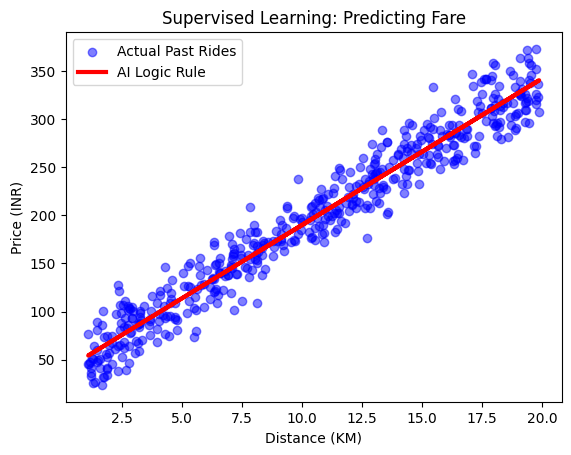

In [2]:
from sklearn.linear_model import LinearRegression

# 1. Split data into X (Input/Distance) and y (Output/Price)
X = uber_data[['Distance_KM']]
y = uber_data['Price_INR']

# 2. Build and train the Supervised AI
price_model = LinearRegression()
price_model.fit(X, y)

# 3. Test it on a brand new 10km ride
new_ride = pd.DataFrame({'Distance_KM': [10]})
predicted_fare = price_model.predict(new_ride)

print(f"The AI predicts a 10km ride will cost: ₹{predicted_fare[0]:.2f}")

# VISUALIZE IT
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Past Rides')
plt.plot(X, price_model.predict(X), color='red', linewidth=3, label='AI Logic Rule')
plt.title("Supervised Learning: Predicting Fare")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

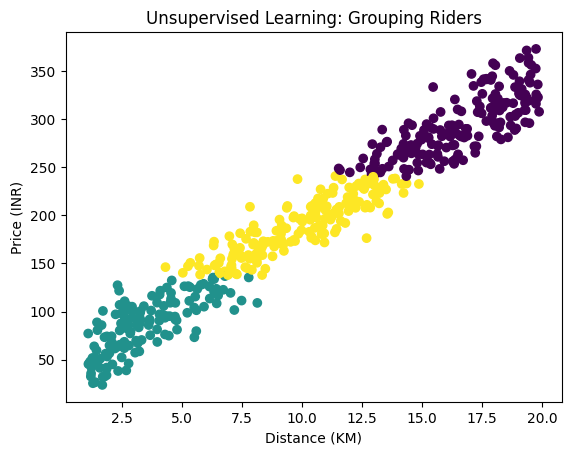

In [3]:
from sklearn.cluster import KMeans

# 1. We just give it the raw data, no labels
data_for_clustering = uber_data[['Distance_KM', 'Price_INR']]

# 2. Tell the AI to find 3 distinct groups (clusters) of riders
# n_clusters is a HYPERPARAMETER
clustering_model = KMeans(n_clusters=3, random_state=42, n_init=10)
uber_data['Rider_Type'] = clustering_model.fit_predict(data_for_clustering)

# VISUALIZE IT
plt.scatter(uber_data['Distance_KM'], uber_data['Price_INR'], c=uber_data['Rider_Type'], cmap='viridis')
plt.title("Unsupervised Learning: Grouping Riders")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (INR)")
plt.show()

In [4]:
import random

# The 3 actions the AI can take
surge_options = [1.0, 1.5, 2.0]
# The AI's memory of how much money each action makes
ai_memory_rewards = [0, 0, 0]
times_tried = [0, 0, 0]

print("AI is learning the best surge price by trial and error...\n")

for ride in range(100):
    # AI randomly picks a surge price to test (Exploration)
    action_index = random.randint(0, 2)
    chosen_surge = surge_options[action_index]

    # Environment Logic (The Real World Reaction)
    if chosen_surge == 1.0:
        reward = 50 # Riders always accept, but profit is low
    elif chosen_surge == 1.5:
        reward = 75 if random.random() > 0.2 else 0 # 20% of riders cancel
    elif chosen_surge == 2.0:
        reward = 100 if random.random() > 0.6 else 0 # 60% of riders cancel angry

    # AI updates its memory based on the reward it got
    ai_memory_rewards[action_index] += reward
    times_tried[action_index] += 1

# Calculate average reward per surge level
average_rewards = [ai_memory_rewards[i] / (times_tried[i] + 1) for i in range(3)]

for i in range(3):
    print(f"Surge {surge_options[i]}x earned an average of ₹{average_rewards[i]:.2f} per ride.")

best_action = surge_options[np.argmax(average_rewards)]
print(f"\nReinforcement Learning complete. AI sets final surge to: {best_action}x")

AI is learning the best surge price by trial and error...

Surge 1.0x earned an average of ₹48.84 per ride.
Surge 1.5x earned an average of ₹57.00 per ride.
Surge 2.0x earned an average of ₹34.29 per ride.

Reinforcement Learning complete. AI sets final surge to: 1.5x


TensorFlow Version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

📥 Downloading PlantVillage dataset...
Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to: /kaggle/input/plantdisease
Dataset folder: /kaggle/input/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot

📂 Using dataset: /kaggle/input/plantdisease/PlantVillage
Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.

🌿 Number of classes: 15

Classes:
0 : Pepper__bell___Bacterial_spot
1 : Pepper__bell___healthy
2 : Potato___Early_blight
3 : Potato___Late_blight
4 : Potato___healthy
5 : Tomato_Bacterial_spot
6 : Tomato_Early_blight
7 : Tomato_Late_blight
8 : Tomato_Leaf_Mold
9 : Tomato_Septoria_leaf_spot
10 : Tomato_Spider_mites_Two_spotted_spider_mite
11 : Tomato__Target_Spot
12 : Tomato__Tomato_YellowLeaf__Curl_Virus
13 : Tomato__Tomato_mosaic_viru

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,570,127 (5.99 MB)

 Trainable params: 1,570,127 (5.99 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Training CNN...

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 57s 35ms/step - accuracy: 0.3813 - loss: 1.9241 - val_accuracy: 0.6409 - val_loss: 1.0787
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6099 - loss: 1.1861 - val_accuracy: 0.7604 - val_loss: 0.7160
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.6915 - loss: 0.9212 - val_accuracy: 0.8115 - val_loss: 0.5437
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7456 - loss: 0.7598 - val_accuracy: 0.7938 - val_loss: 0.6329
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7815 - loss: 0.6447 - val_accuracy: 0.8471 - val_loss: 0.4307
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8032 - loss: 0.5783 - val_accuracy: 0.8723 - val_loss: 0.3560
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8253 - loss: 0.5106 - val_accuracy: 0.8900 - val_loss: 0.3136
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.84

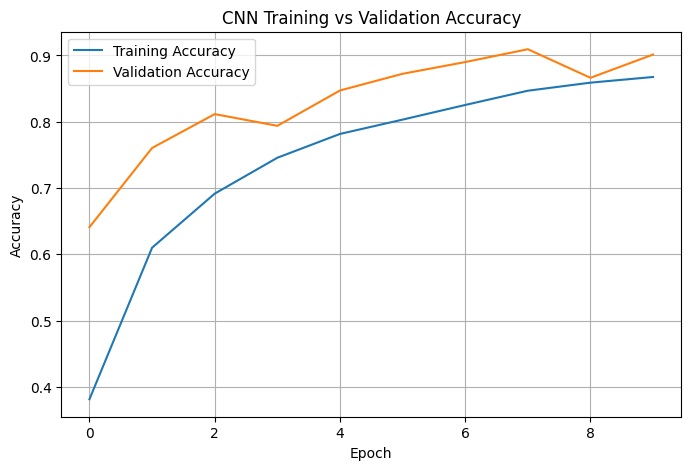

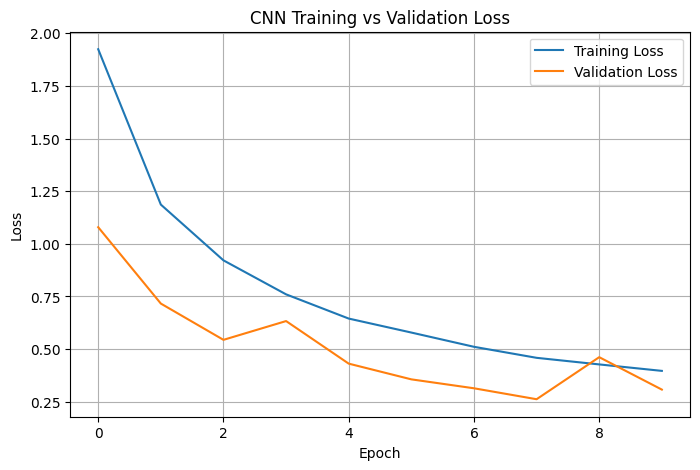


📊 Generating Confusion Matrix...


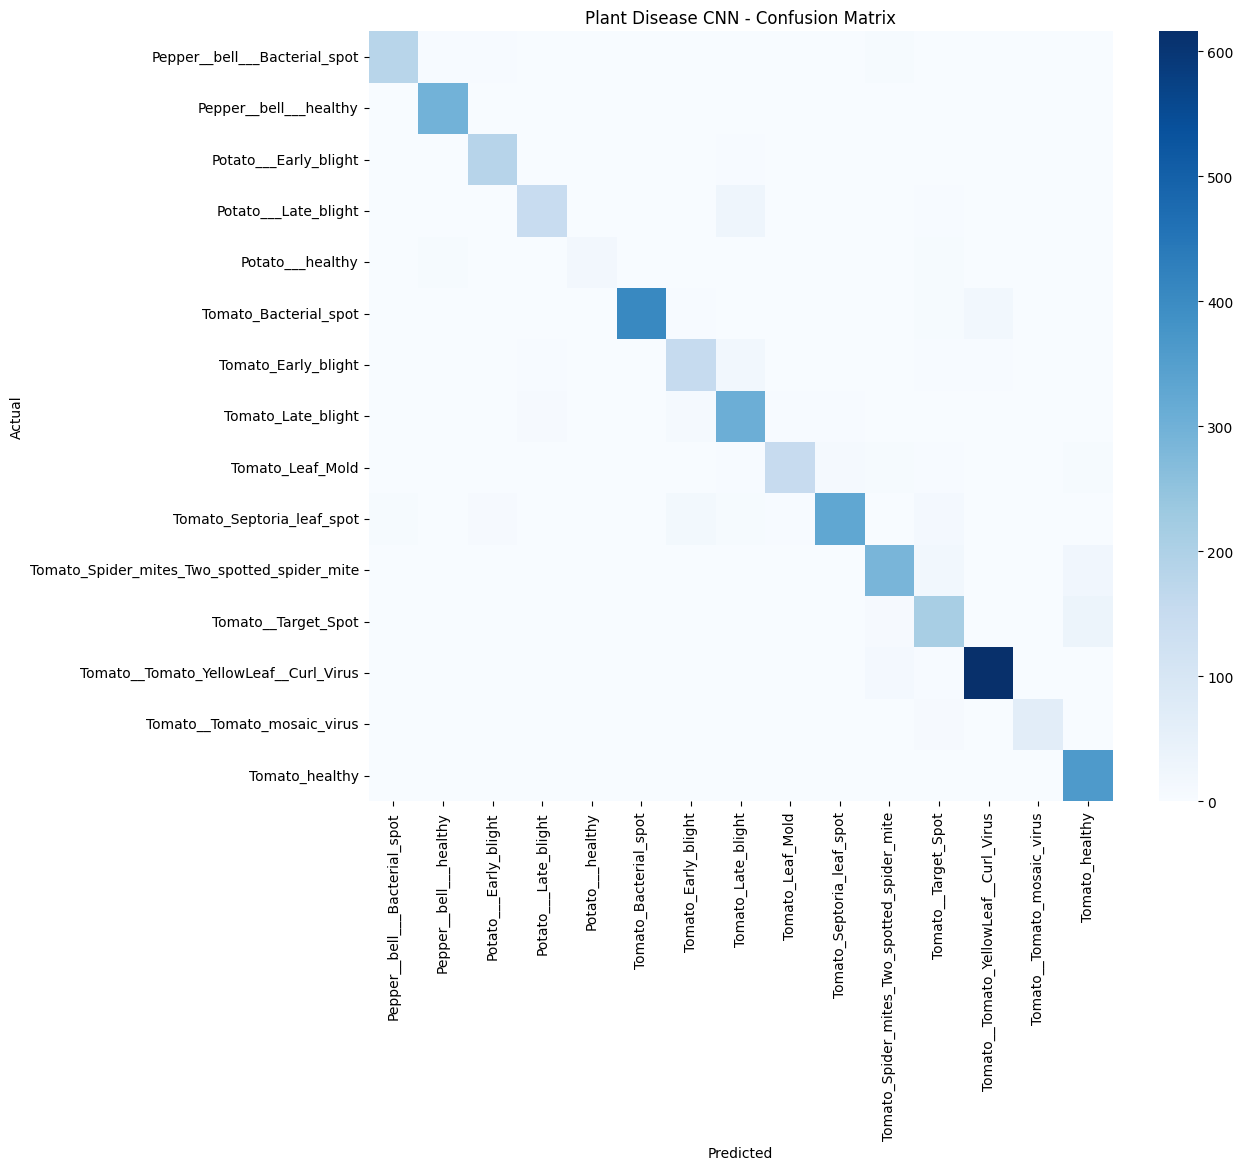


📋 CLASSIFICATION REPORT

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.91      0.93       200
                     Pepper__bell___healthy       0.95      0.99      0.97       302
                      Potato___Early_blight       0.92      0.97      0.94       189
                       Potato___Late_blight       0.91      0.79      0.85       188
                           Potato___healthy       1.00      0.58      0.73        31
                      Tomato_Bacterial_spot       1.00      0.92      0.96       441
                        Tomato_Early_blight       0.80      0.81      0.80       191
                         Tomato_Late_blight       0.82      0.90      0.86       341
                           Tomato_Leaf_Mold       0.96      0.83      0.89       185
                  Tomato_Septoria_leaf_spot       0.94      0.84      0.89       392
Tomato_Spider_mites_Two_spotted_spider

Saving Screenshot 2026-10-06 095823.png to Screenshot 2026-10-06 095823.png


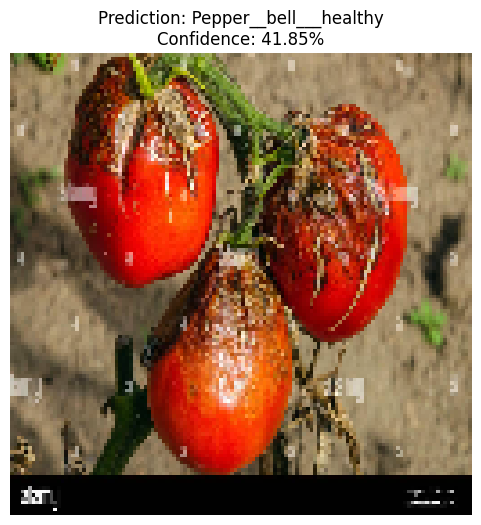


🌿 PREDICTION RESULT
-----------------------------------
Image       : Screenshot 2026-10-06 095823.png
Disease     : Pepper__bell___healthy
Confidence  : 41.85%
-----------------------------------

Top 3 Predictions:
Pepper__bell___healthy : 41.85%
Pepper__bell___Bacterial_spot : 32.01%
Tomato_Late_blight : 9.40%

🎉 PROJECT COMPLETED!


In [5]:
# ============================================================
# 🌱 PLANT DISEASE DETECTION USING CNN
# Complete Google Colab - Single Cell
# ============================================================

# -------------------- 1. INSTALL / IMPORT --------------------
!pip -q install kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# -------------------- 2. DOWNLOAD DATASET --------------------
print("\n📥 Downloading PlantVillage dataset...")

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset downloaded to:", path)

# Find the actual dataset directory
for root, dirs, files in os.walk(path):
    if len(files) > 0:
        print("Dataset folder:", root)
        break

# -------------------- 3. FIND IMAGE DIRECTORY --------------------
# Automatically locate directory containing class folders
data_dir = None

for root, dirs, files in os.walk(path):
    # We need to find the directory that contains subfolders representing classes
    if len(dirs) > 1 and any(os.path.isdir(os.path.join(root, d)) for d in dirs):
        # Double check if these subfolders contain images
        subfolder_path = os.path.join(root, dirs[0])
        subfolder_files = os.listdir(subfolder_path)
        image_count = sum(
            1 for f in subfolder_files
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        )
        if image_count > 0:
            data_dir = root
            break

if data_dir is None:
    raise Exception("Could not find image dataset.")

print("\n📂 Using dataset:", data_dir)

# -------------------- 4. LOAD DATASET --------------------
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\n🌿 Number of classes:", NUM_CLASSES)
print("\nClasses:")
for i, name in enumerate(class_names):
    print(i, ":", name)

# -------------------- 5. OPTIMIZE DATA PIPELINE --------------------
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# -------------------- 6. DATA AUGMENTATION --------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# -------------------- 7. BUILD CNN MODEL --------------------
model = models.Sequential([

    # Input
    layers.Input(shape=(128, 128, 3)),

    # Normalize pixels
    layers.Rescaling(1./255),

    # Data augmentation
    data_augmentation,

    # CNN Layer 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # CNN Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # CNN Layer 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # CNN Layer 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Prevent overfitting
    layers.Dropout(0.5),

    # Output
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# -------------------- 8. COMPILE MODEL --------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🧠 CNN MODEL SUMMARY\n")
model.summary()

# -------------------- 9. TRAIN MODEL --------------------
EPOCHS = 10

print("\n🚀 Training CNN...\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# -------------------- 10. EVALUATE MODEL --------------------
loss, accuracy = model.evaluate(val_ds)

print("\n===================================")
print("📊 MODEL PERFORMANCE")
print("===================================")
print(f"Validation Accuracy : {accuracy * 100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")

# -------------------- 11. ACCURACY GRAPH --------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

# -------------------- 12. LOSS GRAPH --------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

# -------------------- 13. CONFUSION MATRIX --------------------
print("\n📊 Generating Confusion Matrix...")

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Plant Disease CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# -------------------- 14. CLASSIFICATION REPORT --------------------
print("\n📋 CLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# -------------------- 15. SAVE MODEL --------------------
model.save("plant_disease_cnn.keras")

print("\n✅ Model saved as: plant_disease_cnn.keras")

# -------------------- 16. TEST YOUR OWN IMAGE --------------------
from google.colab import files

print("\n===================================")
print("🌱 TEST YOUR OWN PLANT IMAGE")
print("===================================")

uploaded = files.upload()

for filename in uploaded.keys():

    img = image.load_img(
        filename,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    print("\n🌿 PREDICTION RESULT")
    print("-----------------------------------")
    print("Image       :", filename)
    print("Disease     :", predicted_class)
    print(f"Confidence  : {confidence:.2f}%")
    print("-----------------------------------")

    # Show top 3 predictions
    top3 = np.argsort(prediction[0])[-3:][::-1]

    print("\nTop 3 Predictions:")

    for i in top3:
        print(
            f"{class_names[i]} : "
            f"{prediction[0][i] * 100:.2f}%"
        )

print("\n🎉 PROJECT COMPLETED!")